<a href="https://colab.research.google.com/github/Varshini200618/Varshini200618/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Generated Images: Larger Grid of Random Samples

In [13]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch # Added torch import

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 20
num_epochs = 10
batch_size = 128
learning_rate = 1e-3

# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize the images to be between 0 and 1
    # (although Sigmoid in VAE decoder outputs 0-1, it's good practice for input)
    # transforms.Normalize(mean=(0.5,), std=(0.5,)) # Not needed for BCE with Sigmoid output
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Using device: {device}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Using device: cuda
Number of training samples: 60000
Number of test samples: 10000


In [14]:
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: 64x7x7
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: 1x28x28
            nn.Sigmoid() # Output pixels between 0 and 1
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [23]:
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x.view(-1, 784), x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD

### Initialize Model, Optimizer, and Loss History

In [17]:
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = {'total': [], 'recon': [], 'kl': []}

print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Sigmoid()
  )
)


### Initialize Model, Optimizer, and Loss History

In [20]:
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    total_epoch_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device).view(-1, 1, 28, 28) # Ensure correct input shape

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, bce_loss, kld_loss = vae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()
        total_recon_loss += bce_loss.item()
        total_kl_loss += kld_loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], ' +
                  f'Loss: {loss.item() / len(data):.4f}, ' +
                  f'Recon Loss: {bce_loss.item() / len(data):.4f}, ' +
                  f'KL Loss: {kld_loss.item() / len(data):.4f}')

    # Store average epoch losses
    avg_epoch_loss = total_epoch_loss / len(train_dataset)
    avg_recon_loss = total_recon_loss / len(train_dataset)
    avg_kl_loss = total_kl_loss / len(train_dataset)

    history['total'].append(avg_epoch_loss)
    history['recon'].append(avg_recon_loss)
    history['kl'].append(avg_kl_loss)

    print(f'====> Epoch {epoch+1} Average loss: {avg_epoch_loss:.4f}, ' +
          f'Avg Recon Loss: {avg_recon_loss:.4f}, Avg KL Loss: {avg_kl_loss:.4f}')

Epoch [1/10], Batch [100/469], Loss: 163.9154, Recon Loss: 145.8916, KL Loss: 18.0238
Epoch [1/10], Batch [200/469], Loss: 137.2714, Recon Loss: 111.3823, KL Loss: 25.8890
Epoch [1/10], Batch [300/469], Loss: 127.5869, Recon Loss: 101.7807, KL Loss: 25.8062
Epoch [1/10], Batch [400/469], Loss: 114.8396, Recon Loss: 88.9688, KL Loss: 25.8708
====> Epoch 1 Average loss: 155.5394, Avg Recon Loss: 132.5818, Avg KL Loss: 22.9576
Epoch [2/10], Batch [100/469], Loss: 116.2017, Recon Loss: 89.6033, KL Loss: 26.5984
Epoch [2/10], Batch [200/469], Loss: 111.1500, Recon Loss: 84.7515, KL Loss: 26.3985
Epoch [2/10], Batch [300/469], Loss: 113.7032, Recon Loss: 87.2576, KL Loss: 26.4456
Epoch [2/10], Batch [400/469], Loss: 112.4423, Recon Loss: 85.4592, KL Loss: 26.9831
====> Epoch 2 Average loss: 114.4522, Avg Recon Loss: 87.8220, Avg KL Loss: 26.6302
Epoch [3/10], Batch [100/469], Loss: 113.2392, Recon Loss: 86.1107, KL Loss: 27.1285
Epoch [3/10], Batch [200/469], Loss: 105.6203, Recon Loss: 79.4

### Plotting Losses

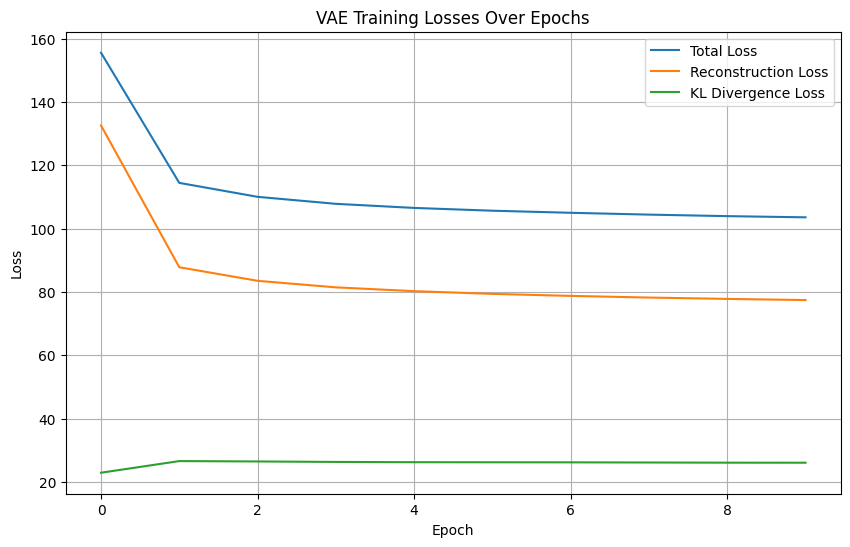

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(history['total'], label='Total Loss')
plt.plot(history['recon'], label='Reconstruction Loss')
plt.plot(history['kl'], label='KL Divergence Loss')
plt.title('VAE Training Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Generate Sample Data Points from Decoder

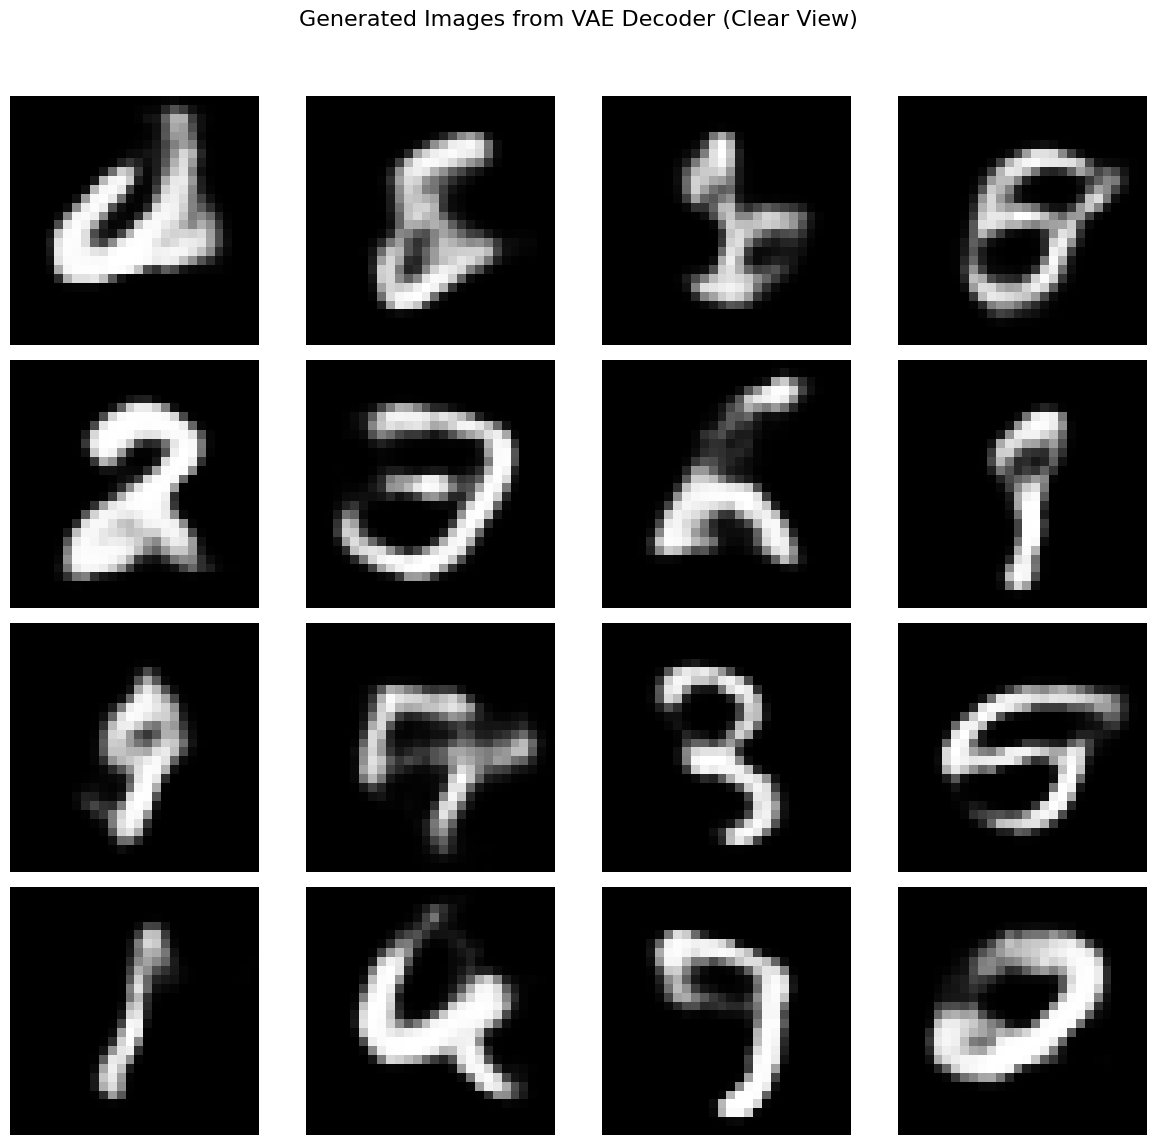

In [28]:
model.eval() # Set model to evaluation mode

with torch.no_grad():
    num_samples = 16 # Reduce number of samples to focus on clarity
    # Generate random latent vectors
    sample = torch.randn(num_samples, latent_dim).to(device)
    # Decode the latent vectors to generate images
    generated_images = model.decoder(model.decoder_input(sample)).cpu()

    # Plot the generated images in a 4x4 grid for better visibility with larger individual images
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12)) # Significantly increased figure size
    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            ax.imshow(generated_images[i].squeeze().numpy(), cmap='gray', interpolation='nearest')
            ax.axis('off')
    plt.suptitle('Generated Images from VAE Decoder (Clear View)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

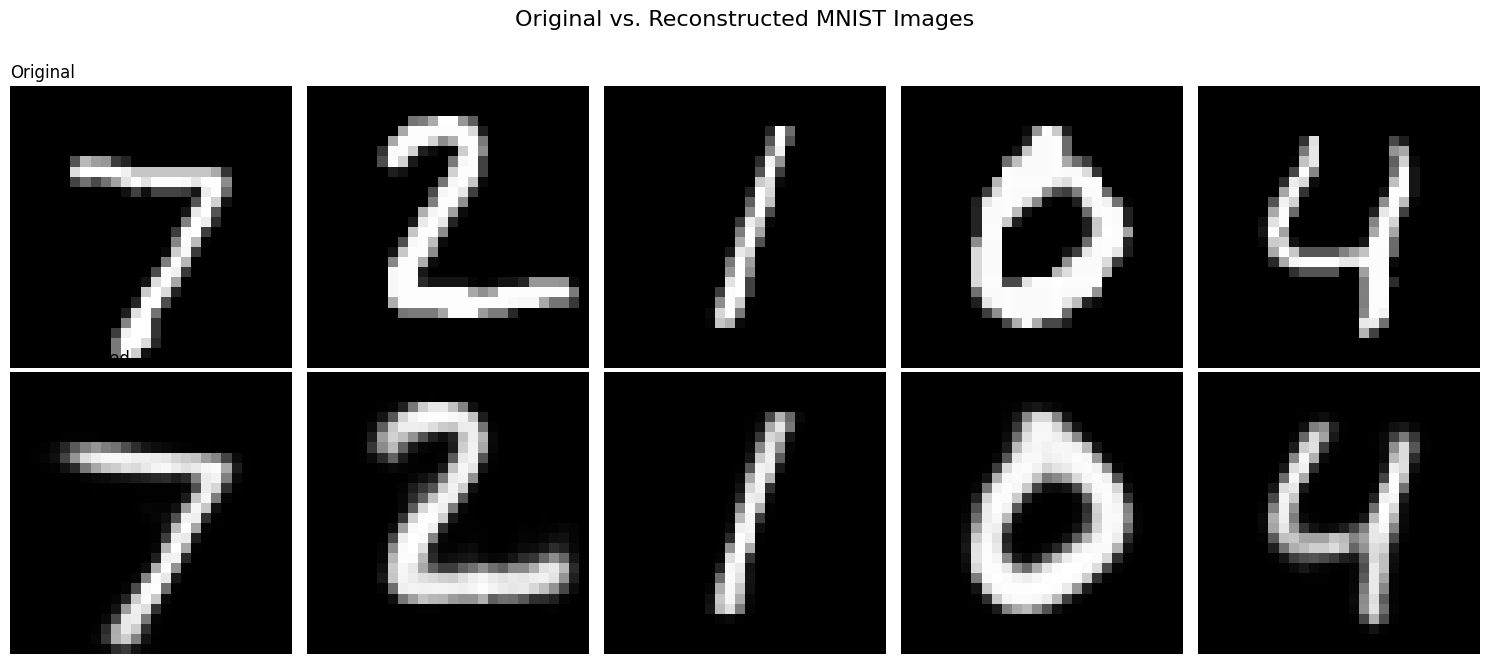

In [29]:
model.eval() # Set model to evaluation mode

with torch.no_grad():
    # Get a batch of test images
    data, _ = next(iter(test_loader))
    data = data.to(device).view(-1, 1, 28, 28)

    # Pass them through the VAE to get reconstructions
    recon_data, _, _ = model(data)

    num_display = 5 # Reduced number of image pairs to display for more clarity
    # Create a figure with 2 rows (original, reconstructed) and num_display columns
    fig, axes = plt.subplots(nrows=2, ncols=num_display, figsize=(3 * num_display, 7)) # Further increased figure size for individual images

    for i in range(num_display):
        # Original images
        ax = axes[0, i]
        ax.imshow(data[i].cpu().squeeze().numpy(), cmap='gray', interpolation='nearest')
        ax.axis('off')
        if i == 0:
            ax.set_title('Original', loc='left')

        # Reconstructed images
        ax = axes[1, i]
        ax.imshow(recon_data[i].cpu().squeeze().numpy(), cmap='gray', interpolation='nearest')
        ax.axis('off')
        if i == 0:
            ax.set_title('Reconstructed', loc='left')

    plt.suptitle('Original vs. Reconstructed MNIST Images', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [16]:
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = {'total': [], 'recon': [], 'kl': []}

print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Sigmoid()
  )
)


### Training Loop

In [24]:
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    total_epoch_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device).view(-1, 1, 28, 28) # Ensure correct input shape

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, bce_loss, kld_loss = vae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()
        total_recon_loss += bce_loss.item()
        total_kl_loss += kld_loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], ' +
                  f'Loss: {loss.item() / len(data):.4f}, ' +
                  f'Recon Loss: {bce_loss.item() / len(data):.4f}, ' +
                  f'KL Loss: {kld_loss.item() / len(data):.4f}')

    # Store average epoch losses
    avg_epoch_loss = total_epoch_loss / len(train_dataset)
    avg_recon_loss = total_recon_loss / len(train_dataset)
    avg_kl_loss = total_kl_loss / len(train_dataset)

    history['total'].append(avg_epoch_loss)
    history['recon'].append(avg_recon_loss)
    history['kl'].append(avg_kl_loss)

    print(f'====> Epoch {epoch+1} Average loss: {avg_epoch_loss:.4f}, ' +
          f'Avg Recon Loss: {avg_recon_loss:.4f}, Avg KL Loss: {avg_kl_loss:.4f}')

Epoch [1/10], Batch [100/469], Loss: 101.6313, Recon Loss: 75.9207, KL Loss: 25.7106
Epoch [1/10], Batch [200/469], Loss: 99.4836, Recon Loss: 74.2589, KL Loss: 25.2247
Epoch [1/10], Batch [300/469], Loss: 105.7278, Recon Loss: 79.9388, KL Loss: 25.7890
Epoch [1/10], Batch [400/469], Loss: 107.0394, Recon Loss: 80.1782, KL Loss: 26.8613
====> Epoch 1 Average loss: 103.2126, Avg Recon Loss: 77.1714, Avg KL Loss: 26.0412
Epoch [2/10], Batch [100/469], Loss: 103.6350, Recon Loss: 78.0325, KL Loss: 25.6025
Epoch [2/10], Batch [200/469], Loss: 104.6493, Recon Loss: 77.7981, KL Loss: 26.8512
Epoch [2/10], Batch [300/469], Loss: 99.2335, Recon Loss: 74.2361, KL Loss: 24.9974
Epoch [2/10], Batch [400/469], Loss: 101.1601, Recon Loss: 76.6685, KL Loss: 24.4916
====> Epoch 2 Average loss: 102.8980, Avg Recon Loss: 76.8889, Avg KL Loss: 26.0090
Epoch [3/10], Batch [100/469], Loss: 100.4909, Recon Loss: 74.9604, KL Loss: 25.5305
Epoch [3/10], Batch [200/469], Loss: 103.2324, Recon Loss: 77.6937, K

### Plotting Losses